In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numbers_parser import Document
from pathlib import Path

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Load the Beta Decay Data from Numbers file
numbers_file = Path("/Users/joshuaclavecillas/anaconda_projects/Intermediate_lab_folder/Beta Decay 1s Data.numbers")
doc = Document(str(numbers_file))

# Extract data from the spreadsheet
sheet = doc.sheets[0]
table = sheet.tables[0]

# Extract counts column
counts_data = []
headers = None

for i, row in enumerate(table.rows()):
    row_values = [cell.value if hasattr(cell, 'value') else None for cell in row]
    
    if i == 0:
        headers = row_values
    else:
        # Extract the "Counts" column (index 1)
        if len(row_values) > 1 and row_values[1] is not None:
            counts_data.append(row_values[1])

# Convert to numpy array for easier calculations
counts = np.array(counts_data)

print(f"Data successfully loaded!")
print(f"Number of measurements: {len(counts)}")
print(f"First 10 count values: {counts[:10]}")
print(f"Data type: {type(counts)}, Data dtype: {counts.dtype}")

Data successfully loaded!
Number of measurements: 1000
First 10 count values: [55. 66. 68. 69. 72. 68. 72. 66. 66. 58.]
Data type: <class 'numpy.ndarray'>, Data dtype: float64


In [20]:
# Calculate Descriptive Statistics
count = len(counts)
mean = np.mean(counts)
median = np.median(counts)
max_val = np.max(counts)
min_val = np.min(counts)

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print(f"Count (Number of Data Points):    {count}")
print(f"Mean:                             {mean:.6f}")
print(f"Median:                           {median:.6f}")
print(f"Maximum:                          {max_val:.6f}")
print(f"Minimum:                          {min_val:.6f}")
# Calculate Standard Deviation Metrics

sample_std = np.std(counts, ddof=1)

# Standard Deviation of the Mean (Standard Error)

std_of_mean = sample_std / np.sqrt(count)

# Standard Deviation of the Standard Deviation


std_of_std = sample_std / np.sqrt(2 * (count - 1))

print("\n" + "=" * 60)
print("STANDARD DEVIATION METRICS")
print("=" * 60)
print(f"Sample Standard Deviation (σ):    {sample_std:.6f}")
print(f"Standard Deviation of the Mean:   {std_of_mean:.6f}")
print(f"Standard Deviation of the Std:    {std_of_std:.6f}")

DESCRIPTIVE STATISTICS
Count (Number of Data Points):    9
Mean:                             5.555556
Median:                           6.000000
Maximum:                          10.000000
Minimum:                          1.000000

STANDARD DEVIATION METRICS
Sample Standard Deviation (σ):    3.205897
Standard Deviation of the Mean:   1.068632
Standard Deviation of the Std:    0.801474


In [13]:
# Compare square root of mean with standard deviation
sqrt_mean = np.sqrt(mean)
ratio = sample_std / sqrt_mean
percent_difference = abs(sample_std - sqrt_mean) / sqrt_mean * 100


print(f"Square Root of Mean (√μ):         {sqrt_mean:.6f}")
print(f"Sample Standard Deviation (σ):    {sample_std:.6f}")
print(f"Ratio (σ / √μ):                   {ratio:.6f}")
print(f"Percent Difference:               {percent_difference:.3f}%")


Square Root of Mean (√μ):         7.725477
Sample Standard Deviation (σ):    7.746129
Ratio (σ / √μ):                   1.002673
Percent Difference:               0.267%


Expanded data: 20 individual measurements
First 20 values: [71 71 73 73 73 74 74 74 74 74 75 75 75 75 76 77 77 77 78 80]
Data range: 71 to 80


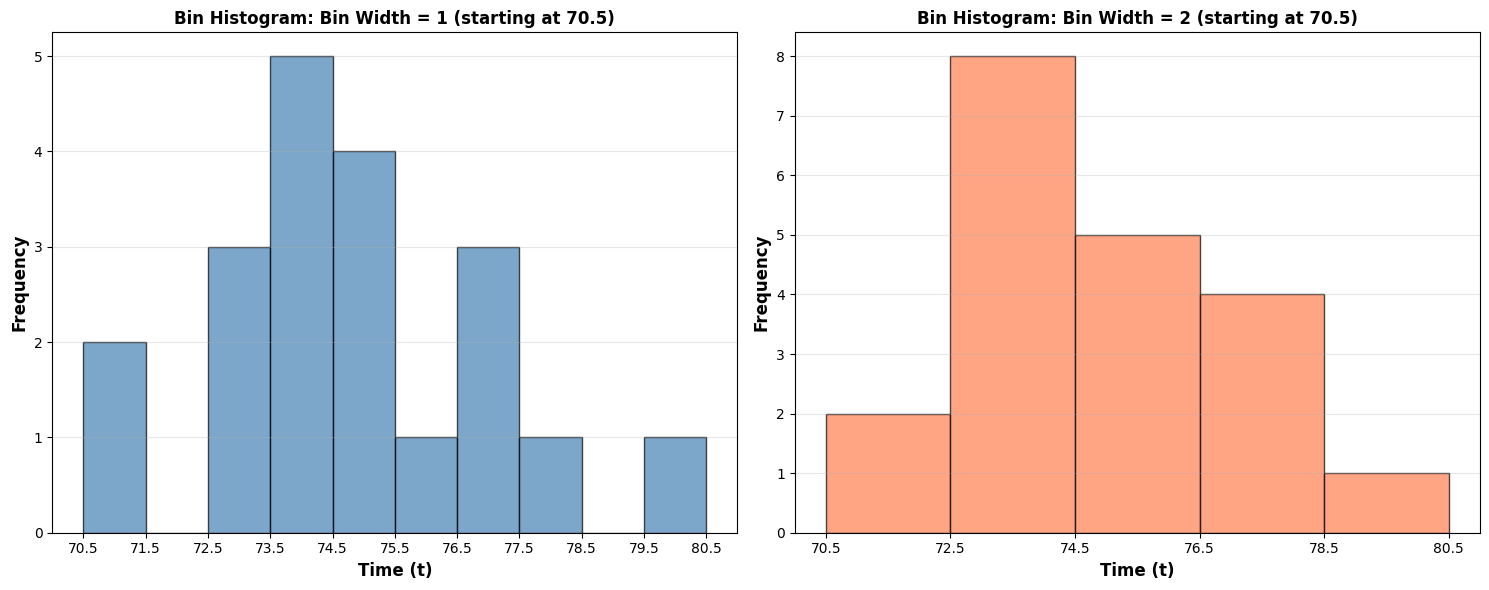

In [17]:

# Time and occurrence data
time_values = np.array([71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
occurrences = np.array([2, 0, 3, 5, 4, 1, 3, 1, 0, 1])

# First, expand the occurrence data into individual data points
# This converts the occurrence counts back to raw individual measurements
expanded_data = []
for time_val, count_val in zip(time_values, occurrences):
    expanded_data.extend([time_val] * int(count_val))

expanded_data = np.array(expanded_data)

print(f"Expanded data: {len(expanded_data)} individual measurements")
print(f"First 20 values: {expanded_data[:20]}")
print(f"Data range: {np.min(expanded_data)} to {np.max(expanded_data)}")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# (a) Histogram with bin width = 1, starting at 70.5
bins_width_1 = np.arange(70.5, 81.5, 1)  # [70.5, 71.5, 72.5, ..., 80.5]
ax1.hist(expanded_data, bins=bins_width_1, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Time (t)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Bin Histogram: Bin Width = 1 (starting at 70.5)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(bins_width_1)

# (b) Histogram with bin width = 2, starting at 70.5
bins_width_2 = np.arange(70.5, 82.5, 2)  # [70.5, 72.5, 74.5, 76.5, 78.5, 80.5]
ax2.hist(expanded_data, bins=bins_width_2, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Time (t)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Bin Histogram: Bin Width = 2 (starting at 70.5)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(bins_width_2)

plt.tight_layout()
plt.savefig('/Users/joshuaclavecillas/anaconda_projects/Intermediate_lab_folder/bin_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


Expanded data: 20 individual measurements
First 20 values: [71 71 73 73 73 74 74 74 74 74 75 75 75 75 76 77 77 77 78 80]
Data range: 71 to 80


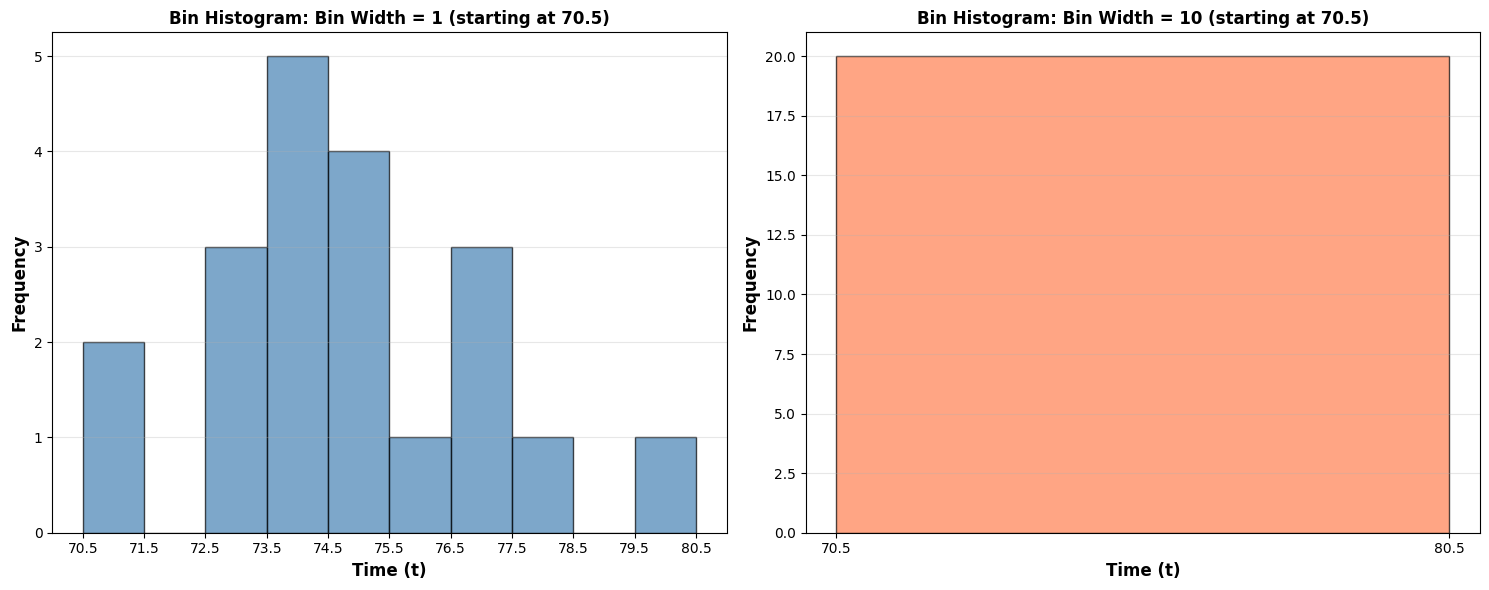

In [18]:
expanded_data = []
for time_val, count_val in zip(time_values, occurrences):
    expanded_data.extend([time_val] * int(count_val))

expanded_data = np.array(expanded_data)

print(f"Expanded data: {len(expanded_data)} individual measurements")
print(f"First 20 values: {expanded_data[:20]}")
print(f"Data range: {np.min(expanded_data)} to {np.max(expanded_data)}")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# (a) Histogram with bin width = 1, starting at 70.5
m=1
bins_width_1 = np.arange(70.5, 81.5, m)  # [70.5, 71.5, 72.5, ..., 80.5]
ax1.hist(expanded_data, bins=bins_width_1, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Time (t)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title(f'Bin Histogram: Bin Width = {m} (starting at 70.5)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(bins_width_1)

# (b) Histogram with bin width = 2, starting at 70.5
n =10
bins_width_2 = np.arange(70.5, 82.5, n)  # [70.5, 72.5, 74.5, 76.5, 78.5, 80.5]
ax2.hist(expanded_data, bins=bins_width_2, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Time (t)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title(f'Bin Histogram: Bin Width = {n} (starting at 70.5)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(bins_width_2)

plt.tight_layout()
plt.savefig('/Users/joshuaclavecillas/anaconda_projects/Intermediate_lab_folder/bin_histograms.png', dpi=150, bbox_inches='tight')
plt.show()





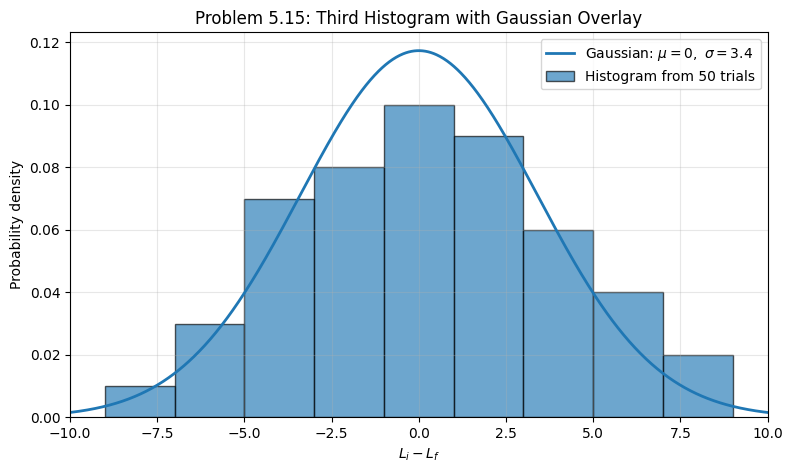

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Problem 5.15 using the 3rd histogram from Problem 5.3
# -----------------------------

# Bin edges from Table 5.3
bin_edges = np.array([-9, -7, -5, -3, -1, 1, 3, 5, 7, 9])


counts = np.array([1, 3, 7, 8, 10, 9, 6, 4, 2])
N = np.sum(counts)
bin_width = bin_edges[1] - bin_edges[0]
heights = counts / (N * bin_width)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mu = 0
sigma = 3.4
x = np.linspace(-10, 10, 1000)
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))


plt.figure(figsize=(9, 5))
plt.bar(
    bin_centers,
    heights,
    width=bin_width,
    align='center',
    edgecolor='black',
    alpha=0.65,
    label='Histogram from 50 trials'
)

plt.plot(x, gaussian, linewidth=2, label=r'Gaussian: $\mu=0,\ \sigma=3.4$')

plt.xlabel(r'$L_i - L_f$')
plt.ylabel('Probability density')
plt.title('Problem 5.15: Third Histogram with Gaussian Overlay')
plt.xlim(-10, 10)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [21]:
counts = np.array([75,75,76,76,76,79,79,80])

# Calculate Descriptive Statistics
count = len(counts)
mean = np.mean(counts)
median = np.median(counts)
max_val = np.max(counts)
min_val = np.min(counts)

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print(f"Count (Number of Data Points):    {count}")
print(f"Mean:                             {mean:.6f}")
print(f"Median:                           {median:.6f}")
print(f"Maximum:                          {max_val:.6f}")
print(f"Minimum:                          {min_val:.6f}")
# Calculate Standard Deviation Metrics

sample_std = np.std(counts, ddof=1)

# Standard Deviation of the Mean (Standard Error)

std_of_mean = sample_std / np.sqrt(count)

# Standard Deviation of the Standard Deviation


std_of_std = sample_std / np.sqrt(2 * (count - 1))

print("\n" + "=" * 60)
print("STANDARD DEVIATION METRICS")
print("=" * 60)
print(f"Sample Standard Deviation (σ):    {sample_std:.6f}")
print(f"Standard Deviation of the Mean:   {std_of_mean:.6f}")
print(f"Standard Deviation of the Std:    {std_of_std:.6f}")

DESCRIPTIVE STATISTICS
Count (Number of Data Points):    8
Mean:                             77.000000
Median:                           76.000000
Maximum:                          80.000000
Minimum:                          75.000000

STANDARD DEVIATION METRICS
Sample Standard Deviation (σ):    2.000000
Standard Deviation of the Mean:   0.707107
Standard Deviation of the Std:    0.534522
